### Importing Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import spacy
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,roc_auc_score, precision_score, recall_score,f1_score
from sklearn.model_selection import RandomizedSearchCV

### Data Importation

In [2]:
df = pd.read_csv('fake_job_postings.csv')
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [4]:
df.isna().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.shape

(17880, 18)

In [7]:
df = df.drop(columns=["job_id", "department", "salary_range"])
df.dropna(subset=["description"], inplace=True)

In [8]:
df["location"] = df["location"].fillna("Unknown")

In [9]:
df["industry"] = df["industry"].fillna("Unknown")

In [10]:
text_cols = ["company_profile","description", "requirements", "benefits","function"]
df[text_cols] = df[text_cols].fillna("")


In [11]:
binary_cols = ["has_company_logo","has_questions"]

df[binary_cols] = df[binary_cols].fillna(0)

In [12]:
cat_cols = ["employment_type",
    "required_experience",
    "required_education"
]

df[cat_cols] = df[cat_cols].fillna("Unknown")

In [13]:
df.isna().sum()

title                  0
location               0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
dtype: int64

In [14]:
df["fraudulent"].value_counts(normalize=True) * 100

fraudulent
0    95.161922
1     4.838078
Name: proportion, dtype: float64

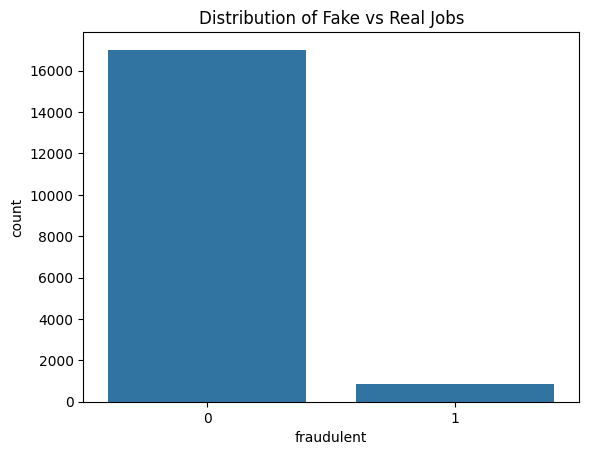

In [15]:
sns.countplot(data=df, x="fraudulent")
plt.title("Distribution of Fake vs Real Jobs")
plt.show()

### Data Visualisation

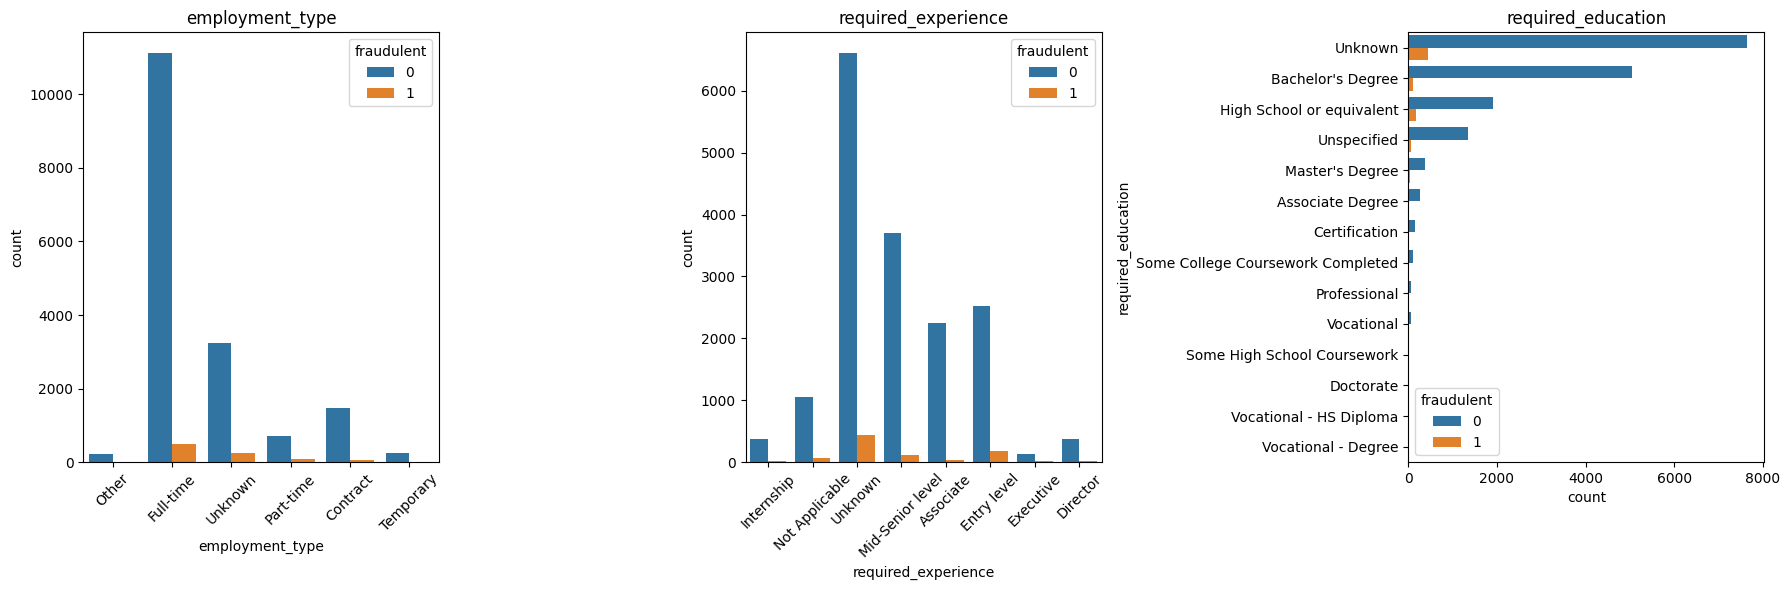

In [16]:
n_cols = len(cat_cols)

fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 6))

if n_cols == 1:
    axes = [axes]

for i, col in enumerate(cat_cols):
    if col == "required_education":
        # Horizontal orientation avoids overlapping long category labels
        order = df[col].value_counts().index
        sns.countplot(data=df, y=col, hue="fraudulent", ax=axes[i], order=order)
        axes[i].set_title(col)
    else:
        sns.countplot(data=df, x=col, hue="fraudulent", ax=axes[i])
        axes[i].set_title(col)
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

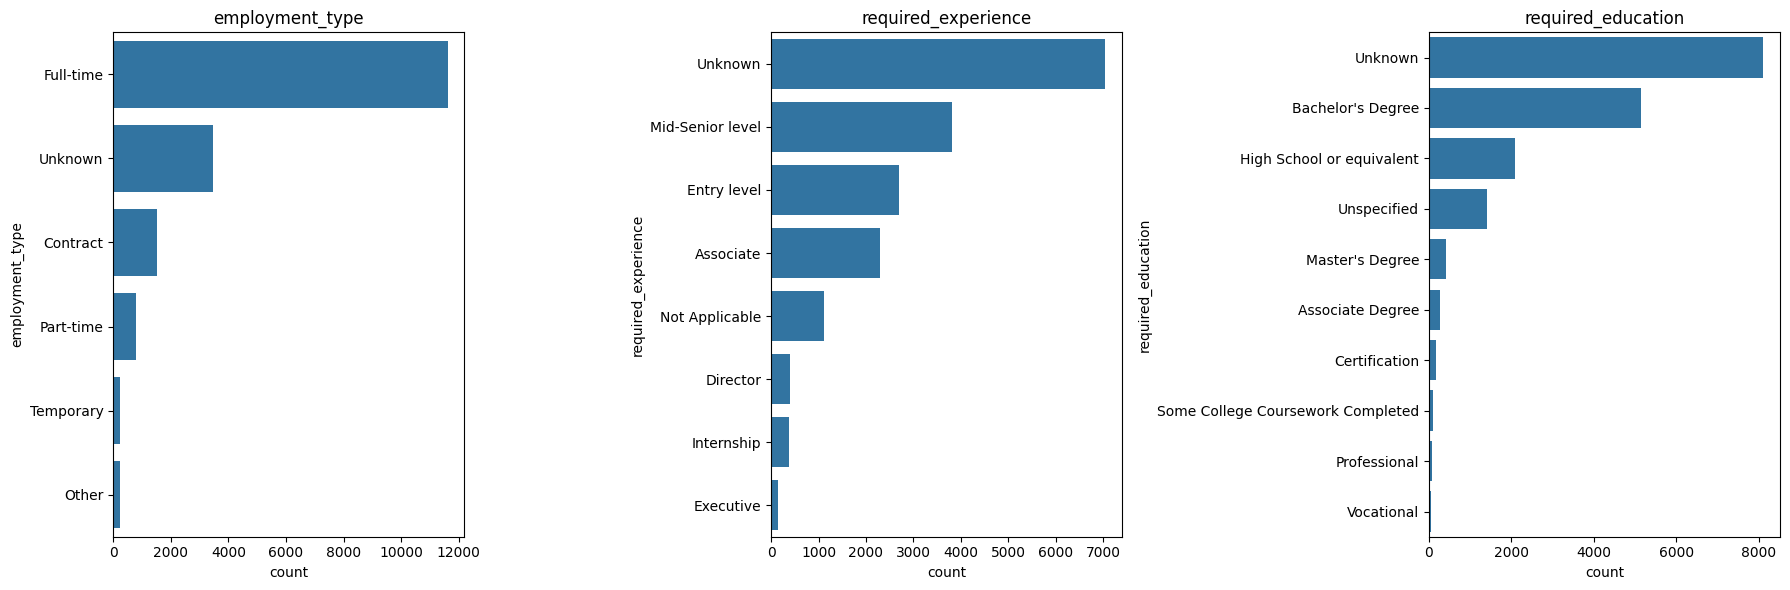

In [17]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(6*len(cat_cols), 6))
[sns.countplot(data=df, y=col, order=df[col].value_counts().head(10).index, ax=axes[i]).set_title(col) for i, col in enumerate(cat_cols)]
plt.tight_layout()
plt.show()

### Feature Engineering

In [18]:
df.columns

Index(['title', 'location', 'company_profile', 'description', 'requirements',
       'benefits', 'telecommuting', 'has_company_logo', 'has_questions',
       'employment_type', 'required_experience', 'required_education',
       'industry', 'function', 'fraudulent'],
      dtype='str')

In [19]:
columns = ['telecommuting','has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent']

for col in columns:
    print(f"{col} ===> {df[col].value_counts()}")
    print("                                  ")

telecommuting ===> telecommuting
0    17112
1      767
Name: count, dtype: int64
                                  
has_company_logo ===> has_company_logo
1    14220
0     3659
Name: count, dtype: int64
                                  
has_questions ===> has_questions
0    9087
1    8792
Name: count, dtype: int64
                                  
employment_type ===> employment_type
Full-time    11620
Unknown       3470
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64
                                  
required_experience ===> required_experience
Unknown             7049
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64
                                  
required_education ===> required_education
Unknown                              8104
Bachelor's Degree                    5145
Hig

In [20]:
df["required_education"] = df["required_education"].replace({
    "Unknown": "Unspecified"
})

In [21]:
df['employment_type'] = df['employment_type'].replace("Other","Unknown")
df['employment_type'].value_counts()

employment_type
Full-time    11620
Unknown       3697
Contract      1524
Part-time      797
Temporary      241
Name: count, dtype: int64

In [22]:
df['required_education'].value_counts()

required_education
Unspecified                          9501
Bachelor's Degree                    5145
High School or equivalent            2080
Master's Degree                       416
Associate Degree                      274
Certification                         170
Some College Coursework Completed     102
Professional                           74
Vocational                             49
Some High School Coursework            27
Doctorate                              26
Vocational - HS Diploma                 9
Vocational - Degree                     6
Name: count, dtype: int64

In [23]:
education_map = {
    # School level
    "High School or equivalent": "school",
    "Some High School Coursework": "school",
    "Vocational - HS Diploma": "school",

    # Undergraduate
    "Some College Coursework Completed": "undergraduate",
    "Associate Degree": "undergraduate",

    # Bachelor
    "Bachelor's Degree": "bachelor's degree",

    # Postgraduate
    "Master's Degree": "Master's Degree",
    "Doctorate": "phd completed",

    # Professional skill-based
    "Certification": "professional",
    "Professional": "professional",
    "Vocational": "professional",
    "Vocational - Degree": "professional",

    # Unknown
    "Unspecified": "unknown"
}

df["required_education"] = df["required_education"].map(education_map)
df["required_education"] = df["required_education"].fillna("unknown")

In [24]:
df['required_education'].value_counts()

required_education
unknown              9501
bachelor's degree    5145
school               2116
Master's Degree       416
undergraduate         376
professional          299
phd completed          26
Name: count, dtype: int64

In [25]:
df.sample(5)

,title,location,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
12567,"Internship, Visa and Passport Agency","US, DC, Washington",VisaHQ hires a diverse and internationally min...,#URL_d66665a1f44c600050fa53a8b3eb6066c3c04f7d7...,#NAME?,About #URL_d66665a1f44c600050fa53a8b3eb6066c3c...,0,1,0,Unknown,Internship,unknown,"Leisure, Travel & Tourism",,0
2604,Marketing Consultant,Unknown,"At Total Eclipse we create fun, original, and ...",Total Eclipse is looking for a Marketing Consu...,Has successfully promoted games that became hi...,"The ability to be part of a fun, dynamic and a...",0,1,1,Unknown,Unknown,unknown,Unknown,,0
12643,Head of Marketing,"US, CA, San Francisco",At HoneyBook we’re re-imagining the events ind...,"You are entrepreneurial, product-focused, exec...",Qualifications7+ years of relevant marketing e...,What you'll getA ground floor opportunity to j...,0,1,1,Full-time,Mid-Senior level,bachelor's degree,Computer Software,Marketing,0
5332,WF17 9LU Business Admin Apprenticeship 16-18 y...,"GB, , Birstall",Established on the principles that full time e...,This is fantastic opportunity for someone want...,Government funding is only available for 16-18...,Future prospects,0,1,1,Full-time,Not Applicable,school,Unknown,Administrative,0
14486,UW Internships 2014-15,"US, WA, Seattle",#URL_e08bd09c0b78a30f1de0802b96ff2d19dc5d486af...,DESCRIPTIONWho?#URL_e08bd09c0b78a30f1de0802b96...,"For CS Interns,More likely than not, your role...",At #URL_e08bd09c0b78a30f1de0802b96ff2d19dc5d48...,0,1,0,Temporary,Unknown,bachelor's degree,Computer Software,Engineering,0


In [26]:
df = df.drop(['location'],axis =1)

In [27]:
df.isna().sum()

title                  0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
dtype: int64

### One Hot Encoding

In [28]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)
df.head()

,title,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,industry,function,...,required_experience_Mid-Senior level,required_experience_Not Applicable,required_experience_Unknown,required_education_Master's Degree,required_education_bachelor's degree,required_education_phd completed,required_education_professional,required_education_school,required_education_undergraduate,required_education_unknown
0,Marketing Intern,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,1,0,Unknown,Marketing,...,0,0,0,0,0,0,0,0,0,1
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Marketing and Advertising,Customer Service,...,0,1,0,0,0,0,0,0,0,1
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0,1,0,Unknown,,...,0,0,1,0,0,0,0,0,0,1
3,Account Executive - Washington DC,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Computer Software,Sales,...,1,0,0,0,1,0,0,0,0,0
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Hospital & Health Care,Health Care Provider,...,1,0,0,0,1,0,0,0,0,0


### Text Preprocessing

In [29]:
df['text']= df['title'] + ' '+df['company_profile']+ ' '+df['description']+' '+df['requirements']+' '+df['benefits']+' '+df['industry']+' '+df['function']

In [30]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

In [31]:
def preprocess_batch(texts):
    cleaned = []
    for text in texts:
        text = text.lower()
        text = re.sub(r"<.*?>", " ", text)
        text = re.sub(r"http\S+|www\S+", " ", text)
        text = re.sub(r"\S+@\S+", " ", text)
        text = re.sub(r"\d+", " ", text)
        text = re.sub(r"_+", " ", text)
        cleaned.append(text)

    results = []
    for doc in nlp.pipe(cleaned, batch_size=100):
        tokens = [tok.lemma_ for tok in doc if not (tok.is_stop or tok.is_punct or tok.is_space)]
        results.append(" ".join(tokens))
    return results



In [32]:
df["preprocessed_text"] = preprocess_batch(df["text"].tolist())


In [33]:
df.head()

,title,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,industry,function,...,required_experience_Unknown,required_education_Master's Degree,required_education_bachelor's degree,required_education_phd completed,required_education_professional,required_education_school,required_education_undergraduate,required_education_unknown,text,preprocessed_text
0,Marketing Intern,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,1,0,Unknown,Marketing,...,0,0,0,0,0,0,0,1,"Marketing Intern We're Food52, and we've creat...",marketing intern food create groundbreaking aw...
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Marketing and Advertising,Customer Service,...,0,0,0,0,0,0,0,1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0,1,0,Unknown,,...,1,0,0,0,0,0,0,1,Commissioning Machinery Assistant (CMA) Valor ...,commission machinery assistant cma valor servi...
3,Account Executive - Washington DC,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Computer Software,Sales,...,0,0,1,0,0,0,0,0,Account Executive - Washington DC Our passion ...,account executive washington dc passion improv...
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Hospital & Health Care,Health Care Provider,...,0,0,1,0,0,0,0,0,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solution llc gl...


In [34]:
df.columns

Index(['title', 'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'industry',
       'function', 'fraudulent', 'employment_type_Contract',
       'employment_type_Full-time', 'employment_type_Part-time',
       'employment_type_Temporary', 'employment_type_Unknown',
       'required_experience_Associate', 'required_experience_Director',
       'required_experience_Entry level', 'required_experience_Executive',
       'required_experience_Internship',
       'required_experience_Mid-Senior level',
       'required_experience_Not Applicable', 'required_experience_Unknown',
       'required_education_Master's Degree',
       'required_education_bachelor's degree',
       'required_education_phd completed', 'required_education_professional',
       'required_education_school', 'required_education_undergraduate',
       'required_education_unknown', 'text', 'preprocessed_text'],
      dtype='str')

In [35]:
df1 = df.drop(['title', 'company_profile', 'description', 'requirements', 'benefits','industry', 'function', 'text'],axis=1)

In [36]:
df1.head()

,telecommuting,has_company_logo,has_questions,fraudulent,employment_type_Contract,employment_type_Full-time,employment_type_Part-time,employment_type_Temporary,employment_type_Unknown,required_experience_Associate,...,required_experience_Not Applicable,required_experience_Unknown,required_education_Master's Degree,required_education_bachelor's degree,required_education_phd completed,required_education_professional,required_education_school,required_education_undergraduate,required_education_unknown,preprocessed_text
0,0,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,marketing intern food create groundbreaking aw...
1,0,1,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,1,customer service cloud video production second...
2,0,1,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,1,commission machinery assistant cma valor servi...
3,0,1,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,account executive washington dc passion improv...
4,0,1,1,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,bill review manager spotsource solution llc gl...


### Data Split

In [37]:
X = df1.drop('fraudulent',axis =1)
Y = df1['fraudulent']

In [38]:
X_train, X_test, y_train, y_test = train_test_split( X, Y, test_size = 0.25, random_state = 50)

In [39]:
X_train.shape

(13409, 24)

In [40]:
X_test.columns

Index(['telecommuting', 'has_company_logo', 'has_questions',
       'employment_type_Contract', 'employment_type_Full-time',
       'employment_type_Part-time', 'employment_type_Temporary',
       'employment_type_Unknown', 'required_experience_Associate',
       'required_experience_Director', 'required_experience_Entry level',
       'required_experience_Executive', 'required_experience_Internship',
       'required_experience_Mid-Senior level',
       'required_experience_Not Applicable', 'required_experience_Unknown',
       'required_education_Master's Degree',
       'required_education_bachelor's degree',
       'required_education_phd completed', 'required_education_professional',
       'required_education_school', 'required_education_undergraduate',
       'required_education_unknown', 'preprocessed_text'],
      dtype='str')

### Count Vectoriser 

In [41]:
v= CountVectorizer()
X_train_cv=v.fit_transform(X_train['preprocessed_text'].values)
X_train_cv

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2200515 stored elements and shape (13409, 80775)>

In [42]:
X_train_cv.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(13409, 80775))

In [43]:
v.get_feature_names_out()

array(['aa', 'aaa', 'aaab', ..., 'ﬁber', 'ﬁnd', 'ﬂexible'],
      shape=(80775,), dtype=object)

In [44]:
v.vocabulary_

{'customer': 15839,
 'service': 62380,
 'team': 69384,
 'lead': 37737,
 'novitex': 45140,
 'enterprise': 23063,
 'solution': 64825,
 'pitney': 50167,
 'bow': 8097,
 'management': 39747,
 'deliver': 17473,
 'innovative': 34113,
 'document': 20233,
 'communication': 12655,
 'help': 31201,
 'company': 12934,
 'world': 77127,
 'drive': 20773,
 'business': 8816,
 'process': 53213,
 'efficiency': 21839,
 'increase': 33250,
 'productivity': 53680,
 'reduce': 56872,
 'cost': 14860,
 'improve': 32973,
 'satisfaction': 61059,
 'year': 77555,
 'client': 11533,
 'turn': 73025,
 'integrate': 34548,
 'optimize': 46822,
 'wide': 76422,
 'empower': 22462,
 'employee': 22351,
 'maximize': 41181,
 'result': 59342,
 'trusted': 72909,
 'partner': 48465,
 'continually': 14304,
 'focus': 27687,
 'secure': 61951,
 'technology': 70160,
 'enable': 22490,
 'work': 76798,
 'enhance': 22962,
 'interaction': 34695,
 'growth': 30289,
 'leader': 37745,
 'right': 59846,
 'candidate': 9515,
 'integral': 34544,
 'suppo

In [45]:
feature_names = v.get_feature_names_out()

bad_tokens = [w for w in feature_names if "_" in w]

print(len(bad_tokens))
print(bad_tokens[:20])

1
['comic_strip']


In [46]:
X_test_cv = v.transform(X_test['preprocessed_text'])
X_test_cv

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 732901 stored elements and shape (4470, 80775)>

In [47]:


# other non-text columns (everything except preprocessed_text)
other_cols_train = X_train.drop(columns=['preprocessed_text'])

X_train_final = hstack([X_train_cv, csr_matrix(other_cols_train.values)])


other_cols_test = X_test.drop(columns=['preprocessed_text'])
X_test_final = hstack([X_test_cv, csr_matrix(other_cols_test.values)])

### (Count Vectoriser) Naive Bayes

In [48]:
nb = MultinomialNB()
nb.fit(X_train_final, y_train)

y_pred = nb.predict(X_test_final)
y_proba = nb.predict_proba(X_test_final)[:, 1]


print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      4228
           1       0.90      0.44      0.59       242

    accuracy                           0.97      4470
   macro avg       0.93      0.72      0.79      4470
weighted avg       0.96      0.97      0.96      4470

ROC-AUC: 0.9397332423747234


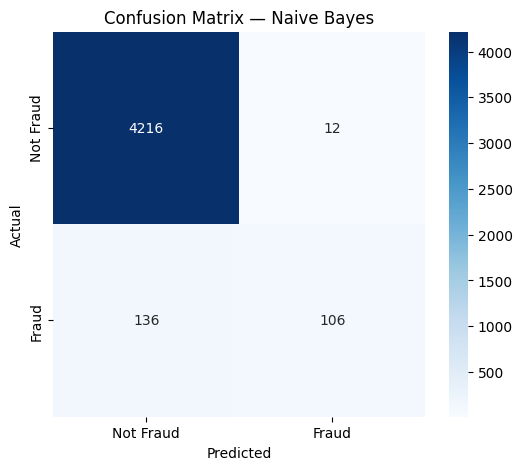

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Naive Bayes')
plt.show()

### (Count Vectoriser) Logistic Regression

In [50]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train_final, y_train)

y_pred_lr = lr.predict(X_test_final)
y_proba_lr = lr.predict_proba(X_test_final)[:, 1]


print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4228
           1       0.83      0.81      0.82       242

    accuracy                           0.98      4470
   macro avg       0.91      0.90      0.91      4470
weighted avg       0.98      0.98      0.98      4470

ROC-AUC: 0.9705935244767274


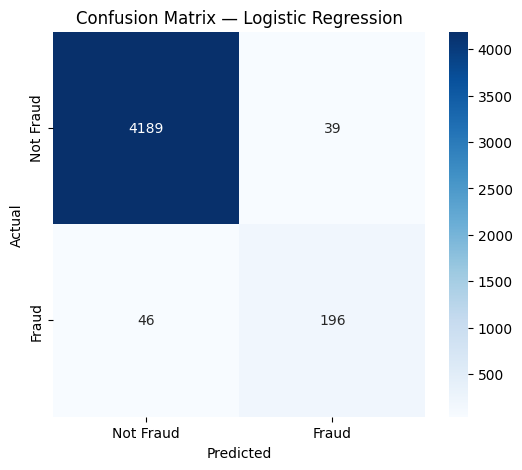

In [51]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Logistic Regression')
plt.show()

### (Count Vectoriser) XGBoost

In [52]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=50
)

xgb.fit(X_train_final, y_train)

y_pred_xgb = xgb.predict(X_test_final)
y_proba_xgb = xgb.predict_proba(X_test_final)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4228
           1       0.96      0.76      0.85       242

    accuracy                           0.99      4470
   macro avg       0.97      0.88      0.92      4470
weighted avg       0.98      0.99      0.98      4470

ROC-AUC: 0.987358968545001


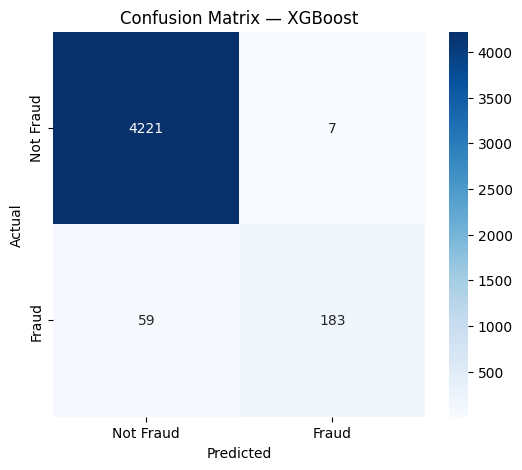

In [53]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — XGBoost')
plt.show()

### Comparison Naive Bayes, Logistic Regression, XGBoost

In [54]:
precision_nb = precision_score(y_test, y_pred)
recall_nb = recall_score(y_test, y_pred)
f1_nb = f1_score(y_test, y_pred)
accuracy_nb = accuracy_score(y_test, y_pred)
roc_auc_nb = roc_auc_score(y_test, y_proba)

precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)

precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)

comparison_df = pd.DataFrame({
    'Naive Bayes': [accuracy_nb, precision_nb, recall_nb, f1_nb, roc_auc_nb],
    'Logistic Regression': [accuracy_lr, precision_lr, recall_lr, f1_lr, roc_auc_lr],
    'XGBoost': [accuracy_xgb, precision_xgb, recall_xgb, f1_xgb, roc_auc_xgb]
}, index=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])

comparison_df

,Naive Bayes,Logistic Regression,XGBoost
Accuracy,0.966890,0.980984,0.985235
Precision,0.898305,0.834043,0.963158
Recall,0.438017,0.809917,0.756198
F1,0.588889,0.821803,0.847222
ROC-AUC,0.939733,0.970594,0.987359


### HyperParameter Tuning - RandomizedSearchCV

In [55]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'gamma': [0, 0.1, 0.3]
}

xgb_base = XGBClassifier(
    # from your earlier run
    eval_metric='logloss',
    random_state=50
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,              # number of random combinations to try
    scoring='f1',           # optimize for F1 on fraud class (or 'roc_auc', 'recall')
    cv=5,
    random_state=50,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_final, y_train)

print("Best params:", random_search.best_params_)
print("Best CV F1:", random_search.best_score_)

best_xgb = random_search.best_estimator_
y_pred_best = best_xgb.predict(X_test_final)
y_proba_best = best_xgb.predict_proba(X_test_final)[:, 1]

print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_best))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.2, 'gamma': 0}
Best CV F1: 0.8064396399768704
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4228
           1       0.97      0.76      0.85       242

    accuracy                           0.99      4470
   macro avg       0.98      0.88      0.92      4470
weighted avg       0.99      0.99      0.98      4470

ROC-AUC: 0.9857238637340986


### Saving your final model

In [56]:
final_model = best_xgb

In [60]:
import joblib

joblib.dump(v, "artifacts/count_vectorizer.pkl")
joblib.dump(final_model, "artifacts/fraud_detection_model.pkl")

feature_columns = other_cols_train.columns.tolist()
joblib.dump(
    feature_columns,
    "artifacts/feature_columns.pkl"
)

['artifacts/feature_columns.pkl']